In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import scipy
from scipy.special import sph_harm_y
import hera_filters as hf

## Notes

* Confirmed unseen is ruining the spherical harmonic transform, need a rigorous method to fill in unseen before the transform
* that leads to more parameters tho?
* filling unseen with the averages of the surrounding pixels seems like a good approx before transforming
* i should do the sph transform manually using scipy.special.sph_harm_y, apply weights for every pixel where unseens have 0 weight while rest have 1

## Explore

In [2]:
m_th = np.load('/Users/dominiv/eigsep/data/beam_th.npy')[:-1]
m_ph = np.load('/Users/dominiv/eigsep/data/beam_ph.npy')[:-1]
NSIDE = hp.get_nside(m_th)

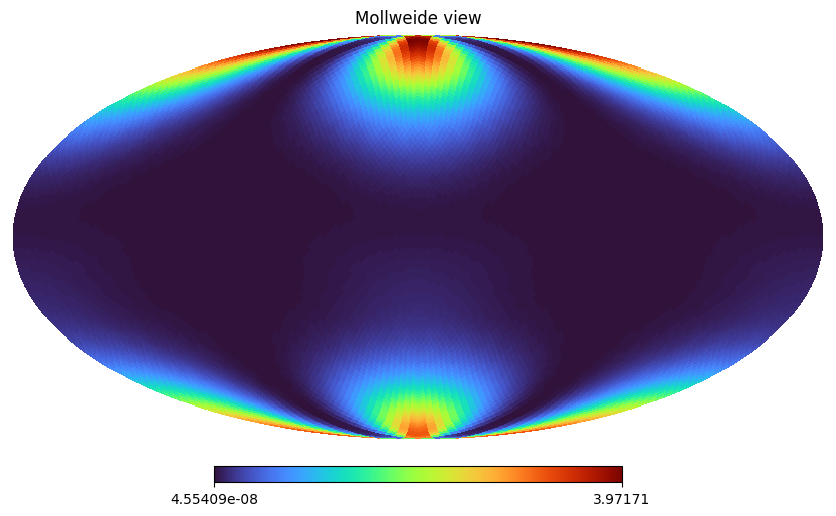

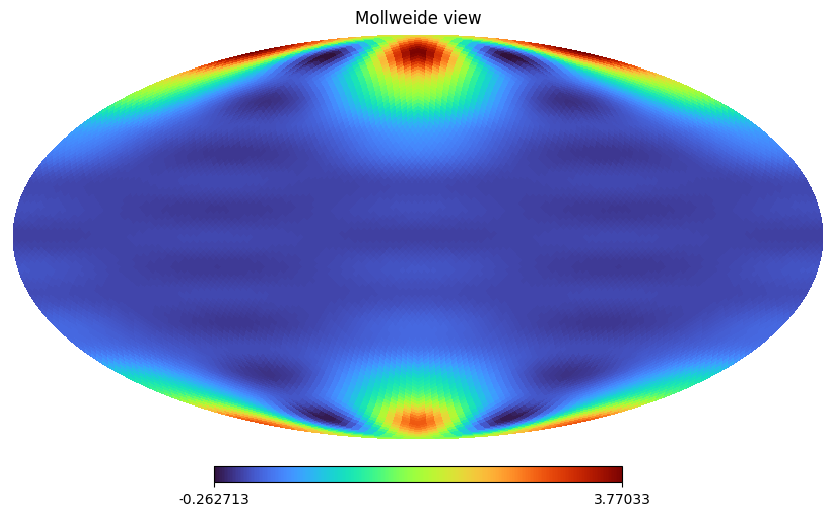

In [3]:
ind = 30
lmax = 16
iter_ = 10
hp.mollview((m_th[ind]), cmap='turbo')
sp_th = hp.map2alm((m_th[ind]), lmax=lmax, iter=iter_)
rec_th = hp.alm2map(sp_th, NSIDE)
hp.mollview(rec_th, cmap='turbo')

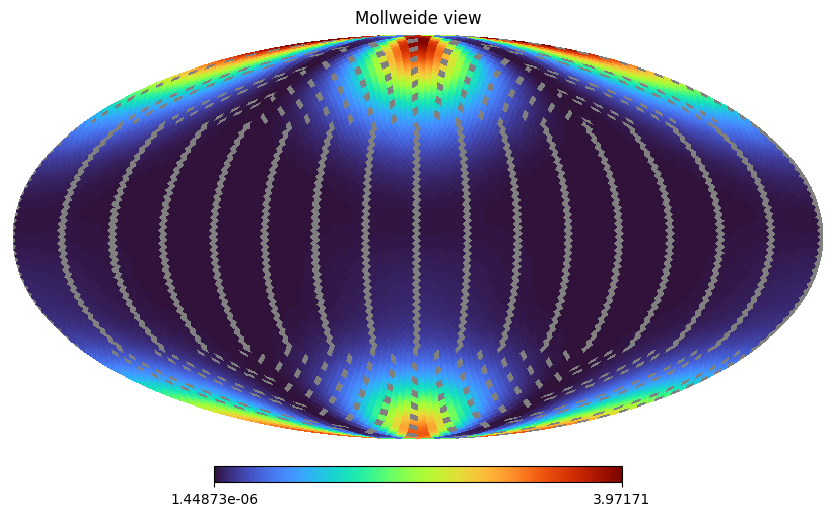

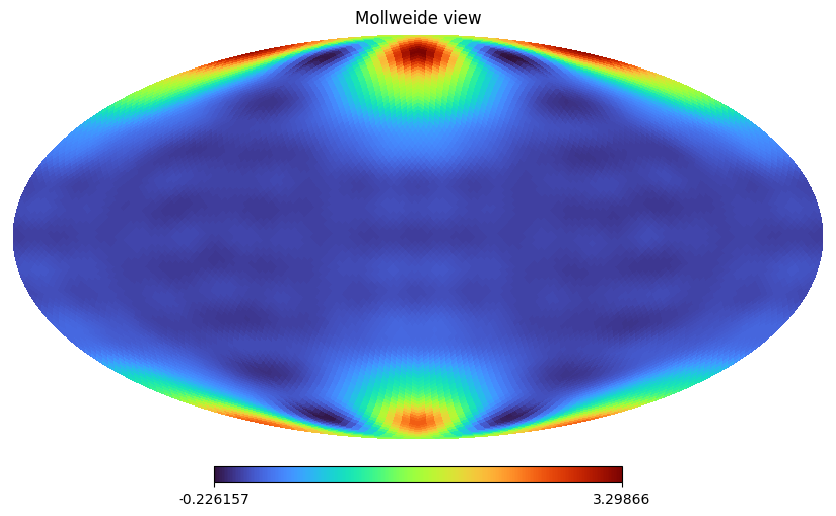

In [4]:
u_th = np.copy(m_th[ind])
u_th[::8] = hp.UNSEEN
u_ind = np.where(u_th == hp.UNSEEN)
hp.mollview(u_th, cmap='turbo')
sp_u = hp.map2alm(u_th, lmax=lmax, iter=iter_)
rec_u = hp.alm2map(sp_u, NSIDE)
hp.mollview(rec_u, cmap='turbo')

In [5]:
u_ind[0].shape, m_th[ind].shape

((1536,), (12288,))

In [6]:
theta, phi = hp.pix2ang(nside=NSIDE, ipix=np.arange(len(u_th)))
print(theta.shape, phi.shape)
m = 2*lmax + 1
ms = np.full_like(a=u_th, fill_value=m)
print(ms.shape)
Ys = sph_harm_y(lmax, m, theta, phi)
print(Ys.shape, u_th.shape)

(12288,) (12288,)
(12288,)
(12288,) (12288,)


In [17]:
Ys = np.stack([sph_harm_y(lmax, m, theta, phi) for m in range(-lmax, lmax+1)], axis=0)
Ys.shape, u_th.shape

((33, 12288), (12288,))

In [19]:
Y = np.zeros(shape=(len(theta), hp.Alm.getsize(lmax)), dtype=np.complex128)
for l in range(lmax+1):
    for m in range(l+1):
        Ys = sph_harm_y(l, m, theta, phi)
        Y[:, m] += Ys

Y.shape

(12288, 153)

In [16]:
a = np.linalg.lstsq(Y, u_th)
a[0].shape

/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_68500/1232850390.py:1: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  a = np.linalg.lstsq(Y, u_th)


(153,)

/Users/dominiv/venv/jupyter/lib/python3.12/site-packages/healpy/projector.py:201: ComplexWarning: Casting complex values to real discards the imaginary part
  img[w] = mpix


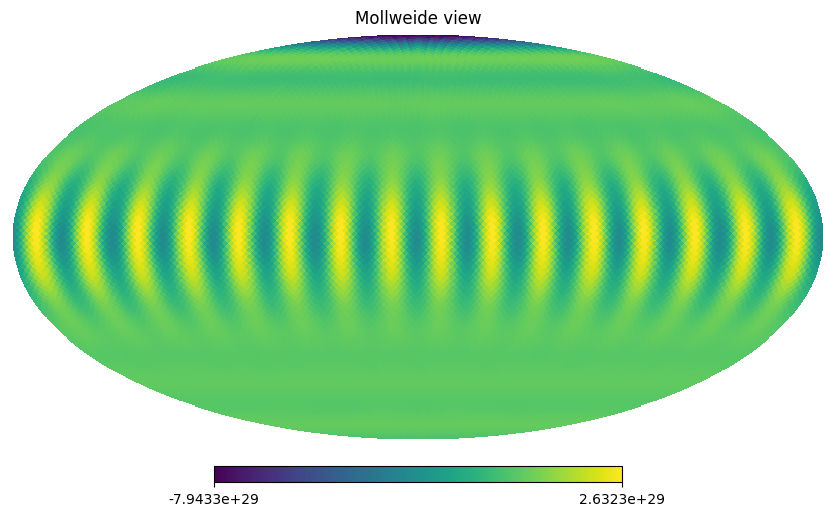

In [14]:
hp.mollview(np.dot(a[0], Y.T))

In [25]:

def build_real_design_matrix(nside, lmax, ipix, nest=False):
    """
    A has shape (n_obs, (lmax+1)^2) and maps real parameters x -> real map values at ipix.
    Parameter layout:
      for l=0..lmax:
        x contains a_{l0}  (real)
        for m=1..l:
          x contains Re(a_{lm}), Im(a_{lm})
    """
    theta, phi = hp.pix2ang(nside, ipix, nest=nest)  # theta=colatitude, phi=longitude

    npar = (lmax + 1) ** 2
    A = np.empty((ipix.size, npar), dtype=np.float64)

    k = 0
    for l in range(lmax + 1):
        # m=0: Y_{l0} is real (with SciPy convention)
        Y = sph_harm_y(l, 0, theta, phi)
        A[:, k] = Y.real
        k += 1

        # m>0: contribution is 2*Re( a_lm * Y_lm )
        for m in range(1, l + 1):
            Y = sph_harm_y(l, m, theta, phi)
            A[:, k]   =  2.0 * Y.real   # coefficient for Re(a_lm)
            A[:, k+1] = -2.0 * Y.imag   # coefficient for Im(a_lm)
            k += 2

    return A

def x_to_alm(x, lmax):
    """Convert the real-parameter vector x into a healpy alm array (m>=0 storage)."""
    alm = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    k = 0
    for l in range(lmax + 1):
        alm[hp.Alm.getidx(lmax, l, 0)] = x[k]  # real
        k += 1
        for m in range(1, l + 1):
            ar, ai = x[k], x[k+1]
            alm[hp.Alm.getidx(lmax, l, m)] = ar + 1j * ai
            k += 2
    return alm

valid = (u_th != hp.UNSEEN) & np.isfinite(u_th)   # keep only real, seen pixels
ipix  = np.where(valid)[0]
print(ipix.shape)
print(u_th.shape[0] - ipix.shape[0], u_ind[0].shape[0])

d = u_th[ipix].astype(float)                  # data vector for kept pixels

A = build_real_design_matrix(nside=hp.get_nside(u_th), lmax=lmax, ipix=ipix)  # your design matrix

x_hat, *_ = np.linalg.lstsq(A, d, rcond=None)

alm_hat = x_to_alm(x_hat, lmax)            # convert to healpy alm (m>=0 storage)
m_fit   = hp.alm2map(alm_hat, hp.get_nside(u_th), lmax=lmax).real

(10752,)
1536 1536


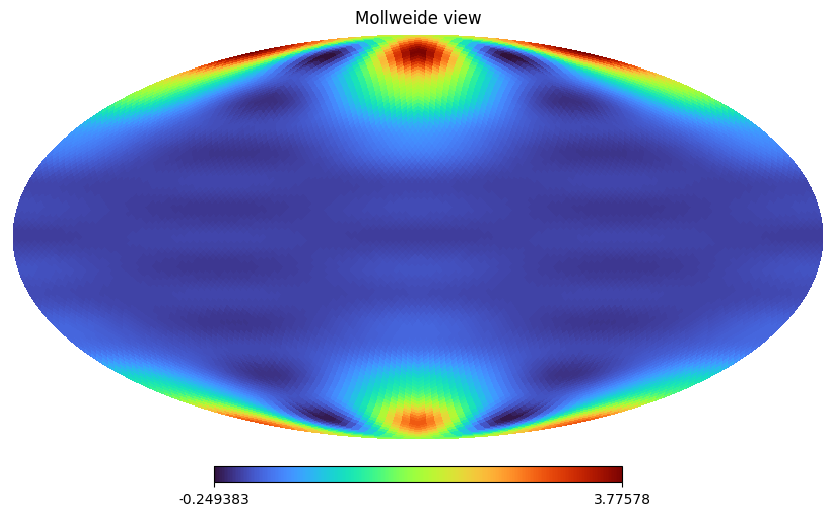

In [21]:
hp.mollview(m_fit, cmap='turbo')

In [243]:
def spectra_sims(m_th, m_ph, alphas, deltas, data, coord=[0, 0, -1]): # does sim at every frequency
    chans = data.shape[1]  
    spectra = jnp.empty(shape=(chans, data.shape[0]))
    for ch in range(chans):
        rx = RotatingAntenna(m_th[ch], m_ph[ch])
        txe1 = jnp.sin(jnp.deg2rad(alphas[ch]))**2
        txe2 = jnp.cos(jnp.deg2rad(alphas[ch]))**2
        tx = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=-32)
        sim_p_rot, hit_pxs = simulate_powers_vmap_phase(rx=rx, tx=tx, az=az_inds, el=el_inds, E1=txe1, E2=txe2, delta_rx=jnp.deg2rad(deltas[ch]), K=1.0, C0=0.0)
        test_data = data[:, ch] * norm[:, ch]
        sim_norm_rot = 1 / jnp.mean(sim_p_rot, axis=0)
        sim_data = sim_p_rot * sim_norm_rot
        # scale_factor = jnp.sum(test_data * sim_data) / jnp.sum(sim_data**2)
        # spectra = spectra.at[i].set(scale_factor * sim_data)
        spectra = spectra.at[ch].set(sim_data)
    return spectra

def fit_hera_pack(nterms, fc, fhw, weights, x, y): # best fits dpss modes
    A, _ = hf.dspec.dpss_operator(x=x, filter_centers=[fc], filter_half_widths=[fhw], nterms=[nterms])
    coeff = hf.dspec.fit_solution_matrix(weights=weights, design_matrix=A)@y
    hera_model = A@coeff
    # print('A', A.shape, 'coeff', coeff.shape, 'model', hera_model.shape, 'data', y.shape)
    return hera_model, coeff

In [250]:
import numpy as np
import healpy as hp
from scipy.linalg import lstsq

# assumes you already have:
# - build_real_design_matrix(nside, lmax, ipix)
# - x_to_alm(x, lmax)

def fit_alms_many_maps(maps, nside, lmax, user_weights=None, nest=False):
    """
    maps: array (n_maps, npix) or (npix,) for single map.
    user_weights: optional array (npix,) with 0/1 or general nonnegative weights.
                 UNSEEN pixels are automatically given weight 0 via masking below.
    Returns: alm array of shape (n_maps, hp.Alm.getsize(lmax))
    """
    maps = np.asarray(maps)
    if maps.ndim == 1:
        maps = maps[None, :]
    n_maps, npix = maps.shape

    # valid pixels per map: not UNSEEN and finite
    valid = (maps != hp.UNSEEN) & np.isfinite(maps)

    # common valid set so we can reuse one A
    common = np.all(valid, axis=0)
    ipix = np.where(common)[0]

    # Build design matrix once on these pixels
    A = build_real_design_matrix(nside, lmax, ipix, nest=nest)   # (n_obs, n_par)

    # Stack all map data as multiple RHS: (n_obs, n_maps)
    D = maps[:, ipix].T.astype(np.float64)

    # Optional extra weights (in addition to dropping UNSEEN)
    if user_weights is not None:
        w = np.asarray(user_weights)[ipix].astype(np.float64)
        w = np.clip(w, 0.0, np.inf)
        sw = np.sqrt(w)
        A = A * sw[:, None]
        D = D * sw[:, None]

    # Solve once for all maps: returns X (n_par, n_maps)
    X, *_ = lstsq(A, D)   # SciPy supports b with shape (M, K) :contentReference[oaicite:2]{index=2}

    # Convert each column of X into healpy alm
    nalm = hp.Alm.getsize(lmax)  # :contentReference[oaicite:3]{index=3}
    alms = np.empty((n_maps, nalm), dtype=np.complex128)
    for i in range(n_maps):
        alms[i] = x_to_alm(X[:, i], lmax)

    return alms


In [277]:
unseen_th = np.copy(m_th)
unseen_th[:, ::16] = hp.UNSEEN

In [278]:
### dpss first, then spherical harmonics
nterms = 15
fc = 0.0
fwh = 1e-2
freqs = np.linspace(0, 250, 1024)
chs = np.arange(16, 1024, 16)
# xs = freqs[::16][13:]
xs = freqs[chs][12:]
# xs = freqs[::16][13:]
weights = np.ones_like(xs)
# rec, coeff = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, weights=weights, x=xs, y=m_th)
rec, coeff = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, weights=weights, x=xs, y=unseen_th)
# rec.shape, coeff.shape

# xhat, *_ = build_real_design_matrix(nside=NSIDE, lmax=lmax, ipix=np.arange(len(m_th)))
# alm_hat = x_to_alm(x_hat, lmax)            # convert to healpy alm (m>=0 storage)
# m_fit   = hp.alm2map(alm_hat, hp.get_nside(u_th), lmax=lmax).real

all_fit = fit_alms_many_maps(maps=coeff, nside=NSIDE, lmax=lmax)
print(all_fit.shape)
maps_fit = np.stack([hp.alm2map(all_fit[i], nside, lmax=lmax).real for i in range(all_fit.shape[0])])
maps_fit.shape

/tmp/ipykernel_58738/1806974285.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  D = maps[:, ipix].T.astype(np.float64)


(15, 153)


(15, 12288)

In [292]:
### spherical harmonics first, then dpss
nterms = 15
fc = 0.0
fwh = 1e-2
freqs = np.linspace(0, 250, 1024)
chs = np.arange(16, 1024, 16)
# xs = freqs[::16][13:]
xs = freqs[chs][12:]
# xs = freqs[::16][13:]
weights = np.ones_like(xs)
# rec, coeff = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, weights=weights, x=xs, y=m_th)
# all_fit = fit_alms_many_maps(maps=m_th, nside=NSIDE, lmax=lmax)
all_fit = fit_alms_many_maps(maps=unseen_th, nside=NSIDE, lmax=lmax)
print(all_fit.shape)
rec, coeff = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, weights=weights, x=xs, y=all_fit)
# rec.shape, coeff.shape
A, _ = hf.dspec.dpss_operator(x=xs, filter_centers=[fc], filter_half_widths=[fwh], nterms=[nterms])
rec_all = A@coeff


# xhat, *_ = build_real_design_matrix(nside=NSIDE, lmax=lmax, ipix=np.arange(len(m_th)))
# alm_hat = x_to_alm(x_hat, lmax)            # convert to healpy alm (m>=0 storage)
# m_fit   = hp.alm2map(alm_hat, hp.get_nside(u_th), lmax=lmax).real

maps_fit = np.stack([hp.alm2map(rec_all[i], nside, lmax=lmax).real for i in range(rec_all.shape[0])])
maps_fit.shape

(51, 153)


(51, 12288)

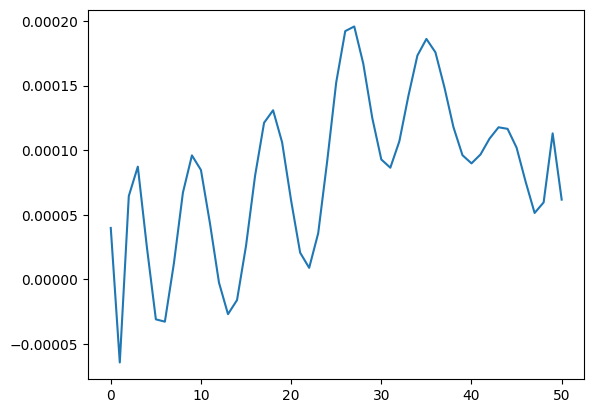

In [298]:
ave_rec = np.mean(maps_fit, axis=1)
ave_map = np.mean(m_th, axis=1)
diffs = ave_map - ave_rec
plt.figure()
plt.plot(diffs)
plt.show()

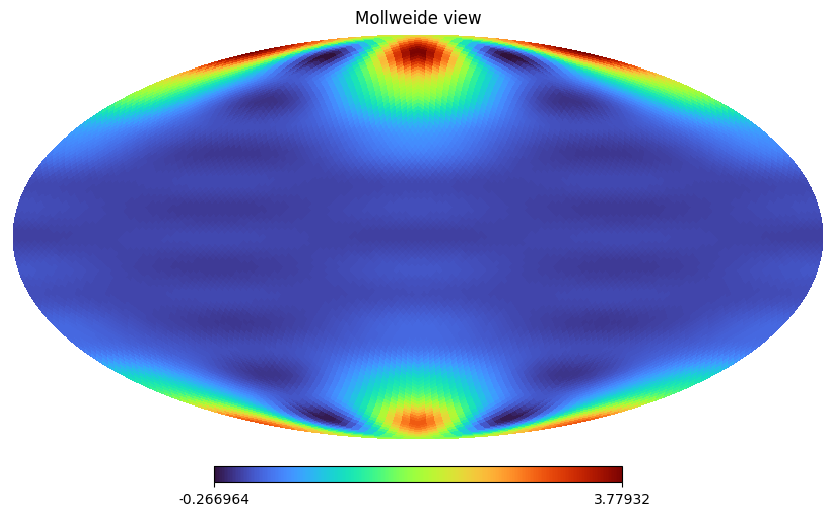

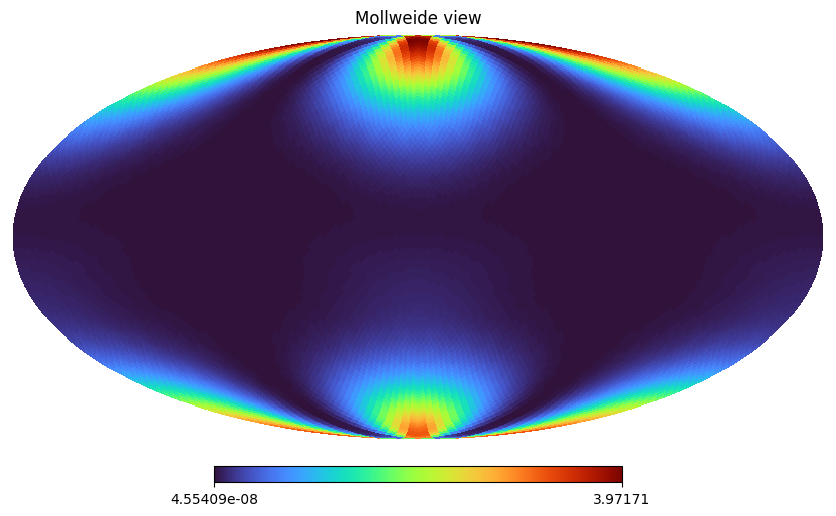

In [297]:
test_ind = 30
hp.mollview(maps_fit[test_ind], cmap='turbo')
hp.mollview(m_th[test_ind]    , cmap='turbo')

In [285]:
coeff.shape

(15, 153)

In [279]:

A, _ = hf.dspec.dpss_operator(x=xs, filter_centers=[fc], filter_half_widths=[fwh], nterms=[nterms])
rec_all = A@maps_fit
rec_all.shape

(51, 12288)

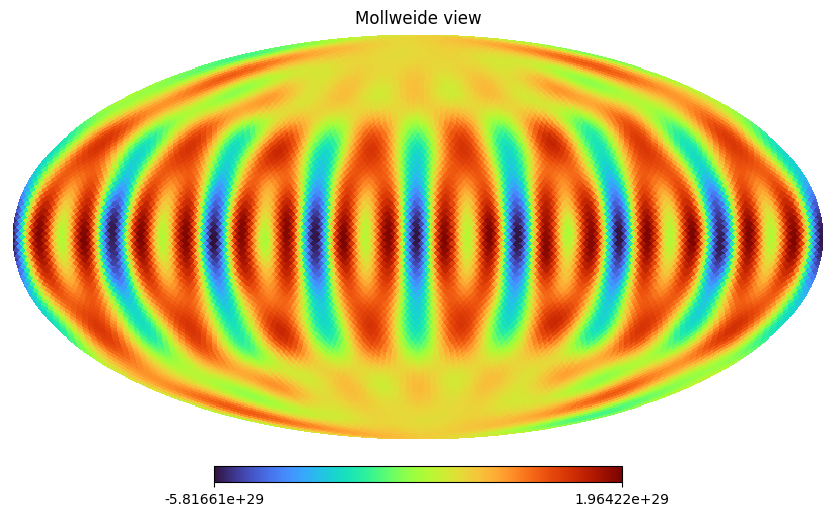

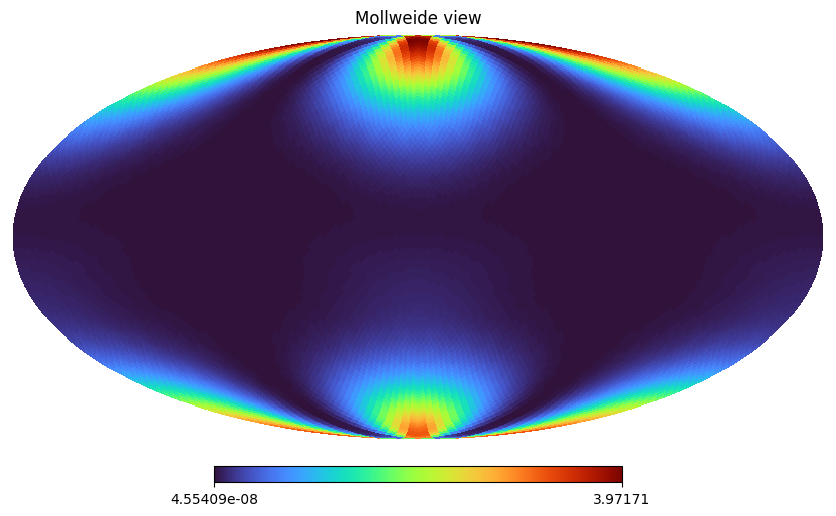

In [281]:
hp.mollview(rec_all[ind], cmap='turbo')
hp.mollview(m_th[ind], cmap='turbo')

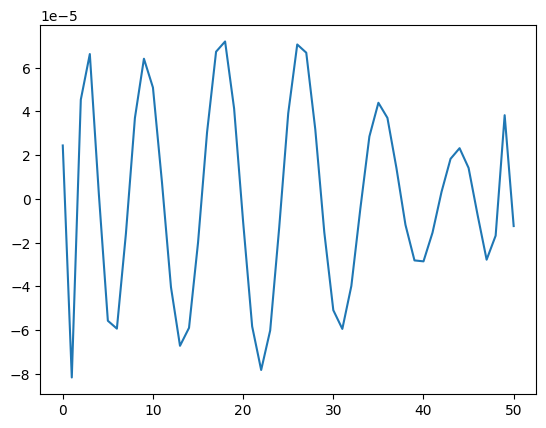

In [275]:
ave_rec = np.mean(rec_all, axis=1)
ave_map = np.mean(m_th, axis=1)
diffs = ave_map - ave_rec
plt.figure()
plt.plot(diffs)
plt.show()

/home/dominiv/venv/jupyter/lib/python3.12/site-packages/healpy/projector.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  img[w] = mpix


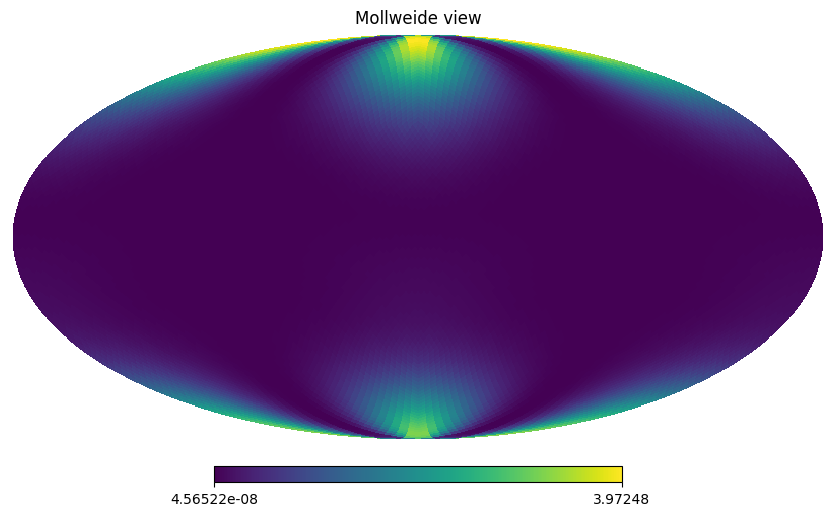

In [249]:
hp.mollview(rec[ind])

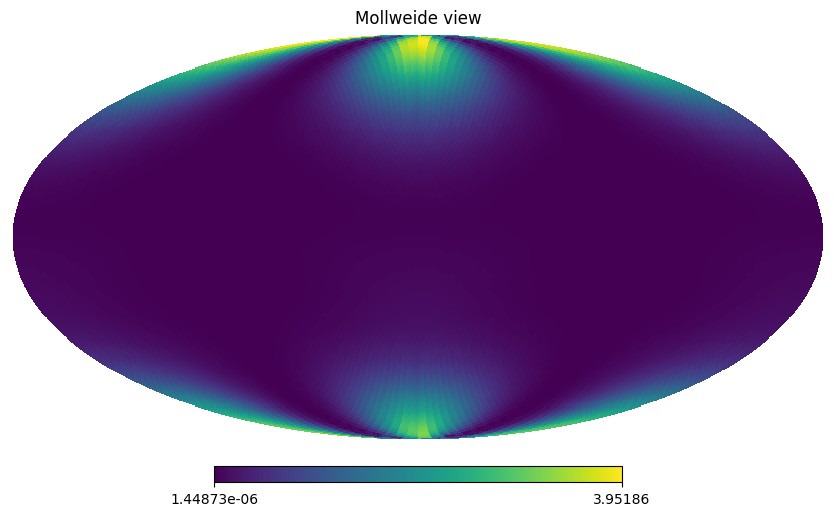

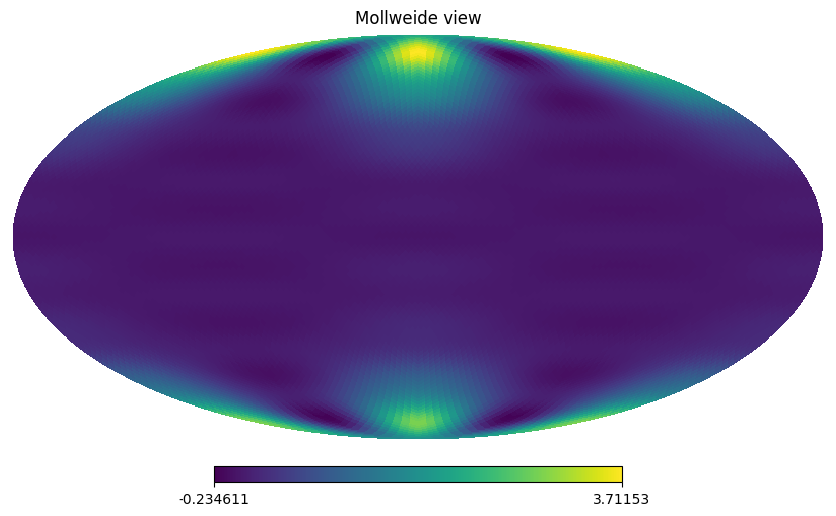

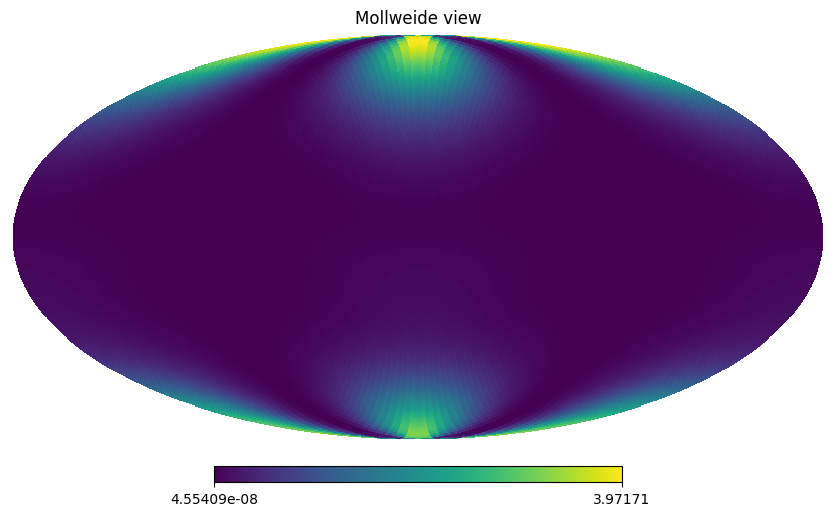

In [143]:
def mean_fill(m, inds):
    nside = hp.get_nside(m)
    npix = hp.nside2npix(nside)
    
    theta, phi = hp.pix2ang(nside, inds)
    nei = hp.get_all_neighbours(nside, theta, phi)
    
    m_fill = m.copy()
    
    fill_mask = np.zeros(npix, dtype=bool)
    fill_mask[inds] = True
    
    nei_vals = m[nei]
    
    bad = (nei < 0) | fill_mask[nei] | (nei_vals == hp.UNSEEN)
    nei_vals = np.where(bad, np.nan, nei_vals)
    
    m_fill[inds] = np.nanmean(nei_vals, axis=0)
    return m_fill

filled = mean_fill(u_th, u_ind)
hp.mollview(filled)

sp_fill = hp.map2alm(filled, lmax=lmax, iter=iter_)
rec_fill = hp.alm2map(sp_fill, NSIDE)
hp.mollview(rec_fill)

hp.mollview(m_th[ind])


In [98]:
np.mean(nei, axis=0)

array([[5.6250000e+00, 1.3250000e+01, 1.9000000e+01, ..., 1.2261000e+04,
        1.2265625e+04, 1.2274750e+04]])

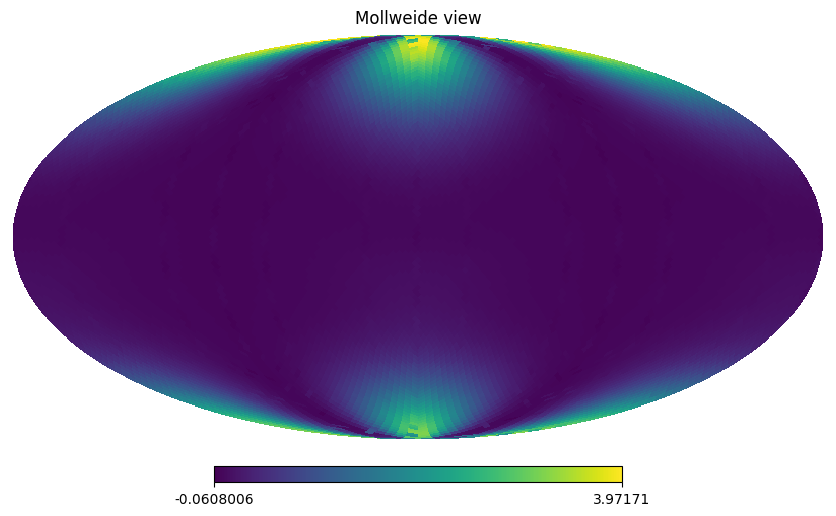

In [5]:
import numpy as np
import healpy as hp
from scipy.sparse.linalg import cg, LinearOperator

def inpaint_smooth_map_mapi(m, lmax=None, lam=1e-2, p=2, sigma=None, tol=1e-10, maxiter=200):
    """
    MAP inpainting with harmonic smoothness prior.
    m: healpy map with hp.UNSEEN holes (scalar, RING).
    lam: regularization strength (bigger => smoother, less faithful to data).
    p: 1 or 2 usually. alpha_l = (l(l+1))^p.
    sigma: optional noise std for seen pixels. If provided, weights are 1/sigma^2 on seen pixels.
           Smaller sigma => forces closer agreement with observed pixels.
    Returns: full-sky filled map, and the fitted alm.
    """
    nside = hp.get_nside(m)
    npix = m.size
    if lmax is None:
        lmax = 3 * nside - 1

    seen = (m != hp.UNSEEN)
    m0 = m.copy()
    m0[~seen] = 0.0  # safe; unseen contribute zero to the data term

    # Pixel weights
    w = np.zeros(npix, dtype=np.float64)
    if sigma is None:
        w[seen] = 1.0
    else:
        w[seen] = 1.0 / (sigma * sigma)

    # Build alpha_l per alm coefficient
    ell, mm = hp.Alm.getlm(lmax)
    alpha = (ell * (ell + 1.0)) ** p
    alpha = alpha.astype(np.float64)
    # leave monopole/dipole unpenalized if you want; otherwise add small floor:
    # alpha = np.maximum(alpha, 1e-12)

    # Right-hand side: Y^T W m
    rhs = hp.map2alm(w * m0, lmax=lmax, iter=0)

    def matvec(a):
        # Compute (Y^T W Y + lam*diag(alpha)) a
        x = hp.alm2map(a, nside=nside, lmax=lmax)
        ya = hp.map2alm(w * x, lmax=lmax, iter=0)
        return ya + lam * (alpha * a)

    nalm = rhs.size
    A = LinearOperator((nalm, nalm), matvec=matvec, dtype=np.complex128)

    a0 = np.zeros_like(rhs)
    alm_hat, info = cg(A, rhs, x0=a0, maxiter=maxiter, atol=tol)

    if info != 0:
        print(f"CG did not fully converge (info={info}). Try larger maxiter or looser tol.")

    m_fill = hp.alm2map(alm_hat, nside=nside, lmax=lmax)

    # Optional: enforce exact observed pixels (useful if you consider them noise-free)
    m_fill[seen] = m[seen]

    return m_fill, alm_hat


rec_smooth = inpaint_smooth_map_mapi(u_th, lmax=16, tol=1e-10, maxiter=1000, p=1, lam=1e-3)

hp.mollview(rec_smooth[0])

In [72]:
import numpy as np
import healpy as hp

gain_map = u_th

def _axisymmetric_profile_db(db_map, obs_mask, nbins=None, smooth_bins=0):
    """
    Build an axisymmetric (theta-only) profile by taking the median in theta bins.
    Missing theta-bins are linearly interpolated.
    """
    nside = hp.get_nside(db_map)
    npix = db_map.size
    theta, _phi = hp.pix2ang(nside, np.arange(npix))  # theta in [0, pi]

    if nbins is None:
        nbins = 4 * nside  # decent default for beams

    edges = np.linspace(0.0, np.pi, nbins + 1)
    bin_idx = np.clip(np.digitize(theta, edges) - 1, 0, nbins - 1)

    prof = np.full(nbins, np.nan, dtype=float)
    obs_bins = np.unique(bin_idx[obs_mask])
    for k in obs_bins:
        vals = db_map[obs_mask & (bin_idx == k)]
        if vals.size:
            prof[k] = np.median(vals)

    # interpolate bins with no data
    x = np.arange(nbins)
    good = np.isfinite(prof)
    if good.sum() >= 2:
        prof[~good] = np.interp(x[~good], x[good], prof[good])
    elif good.sum() == 1:
        prof[~good] = prof[good][0]
    else:
        raise ValueError("No observed pixels to build a profile.")

    # optional light smoothing along theta bins
    if smooth_bins and smooth_bins > 0:
        w = int(smooth_bins)
        kernel = np.ones(2*w + 1) / (2*w + 1)
        prof = np.convolve(prof, kernel, mode="same")

    return prof, bin_idx

def _restrict_m(alm, lmax, mmax):
    """
    Zero out all alm with |m| > mmax. (healpy alm stores m>=0 only)
    """
    idx = np.arange(alm.size)
    ell, m = hp.Alm.getlm(lmax, idx)
    out = alm.copy()
    out[m > mmax] = 0.0
    return out

def inpaint_beam_iterproj(
    gain_map,
    lmax,
    niter=30,
    mmax=0,                 # 0 for axisymmetric, try 2 or 4 for mild asymmetry
    lam=0.0,                # >0 adds extra high-ell suppression (see p)
    p=2,                    # penalty power; 2 corresponds to (ell(ell+1))^2
    bmin_db=None,
    bmax_db=None,
    eps_lin=None,           # small floor before log; if None, inferred from observed
    nbins=None,
    smooth_profile_bins=0,
):
    """
    gain_map: healpy map of power gain (linear units), with hp.UNSEEN in missing pixels
    lmax: band-limit used for the reconstruction
    """
    gain_map = np.asarray(gain_map, dtype=float)
    nside = hp.get_nside(gain_map)

    obs_mask = np.isfinite(gain_map) & (gain_map != hp.UNSEEN)

    if obs_mask.sum() < 10:
        raise ValueError("Too few observed pixels to reconstruct.")

    # choose epsilon (floor) for log, from observed values if not given
    obs_vals = gain_map[obs_mask]
    if eps_lin is None:
        # use a small fraction of a robust low percentile as floor
        lo = np.percentile(obs_vals, 1.0)
        eps_lin = max(1e-30, 0.01 * max(lo, 1e-30))

    # go to dB
    db_map = 10.0 * np.log10(np.maximum(gain_map, 0.0) + eps_lin)

    # bounds in dB (use observed min/max if not provided)
    if bmin_db is None:
        bmin_db = np.min(db_map[obs_mask])
    if bmax_db is None:
        bmax_db = np.max(db_map[obs_mask])

    # init fill with axisymmetric theta-profile median
    prof, bin_idx = _axisymmetric_profile_db(
        db_map, obs_mask, nbins=nbins, smooth_bins=smooth_profile_bins
    )
    filled = db_map.copy()
    miss_mask = ~obs_mask
    filled[miss_mask] = prof[bin_idx[miss_mask]]
    filled = np.clip(filled, bmin_db, bmax_db)

    # precompute ell for filtering
    idx = np.arange(hp.Alm.getsize(lmax))
    ell, m = hp.Alm.getlm(lmax, idx)
    if lam and lam > 0:
        # strong suppression of high-ell wiggles
        filt = 1.0 / (1.0 + lam * (ell * (ell + 1.0))**p)
    else:
        filt = np.ones_like(ell, dtype=float)

    # iterative band-limited projection
    for _ in range(int(niter)):
        alm = hp.map2alm(filled, lmax=lmax, iter=0)  # no UNSEEN present now
        alm = _restrict_m(alm, lmax=lmax, mmax=mmax)
        alm *= filt

        model = hp.alm2map(alm, nside=nside, lmax=lmax, verbose=False)

        # enforce observed pixels exactly
        model[obs_mask] = db_map[obs_mask]

        # enforce bounds
        filled = np.clip(model, bmin_db, bmax_db)

    # back to linear gain (remove eps floor)
    gain_filled = np.maximum(0.0, 10.0**(filled / 10.0) - eps_lin)

    return gain_filled, filled  # (linear gain, dB)

# gain_map is your healpy map in linear power gain, with hp.UNSEEN at missing pixels
nside = hp.get_nside(gain_map)

# Pick a conservative lmax to start. (Example: half of the Nyquist-ish 3*nside-1)
# lmax = (3 * nside - 1) // 2
lmax = 16

gain_filled, db_filled = inpaint_beam_iterproj(
    gain_map,
    lmax=lmax,
    niter=80,
    mmax=0,          # axisymmetric; try 2 or 4 if needed
    lam=1e-2,        # tune; try 0, 1e-7, 1e-6, 1e-5
    p=1,
    smooth_profile_bins=2
)

# Now safe to do spherical harmonics on the filled map:
alm = hp.map2alm(gain_filled, lmax=lmax)  # or use gain_filled if you prefer linear space


/tmp/ipykernel_58738/4223999927.py:121: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  model = hp.alm2map(alm, nside=nside, lmax=lmax, verbose=False)


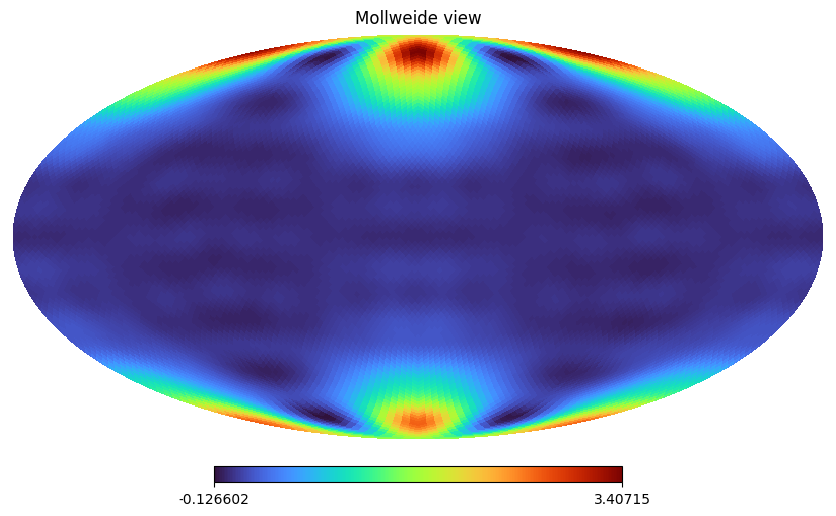

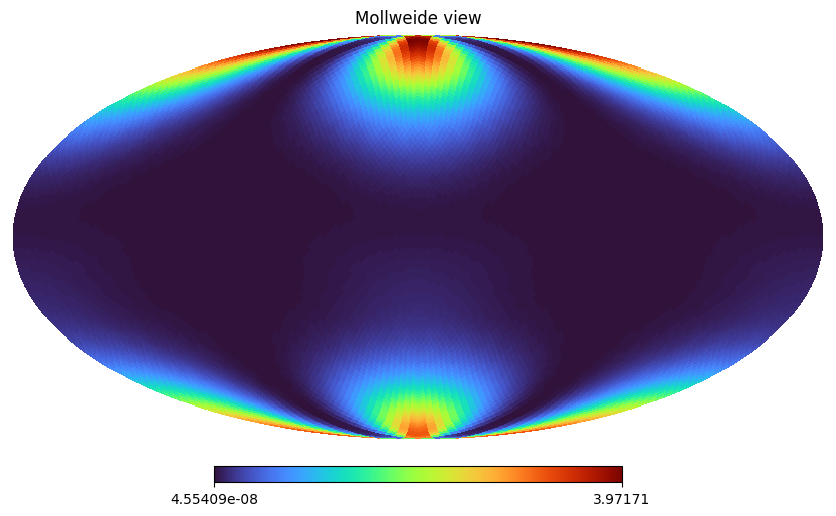

In [73]:
gain_map_r = hp.alm2map(alm, nside)
hp.mollview(gain_map_r, cmap='turbo')
hp.mollview(m_th[ind] , cmap='turbo')